cuda


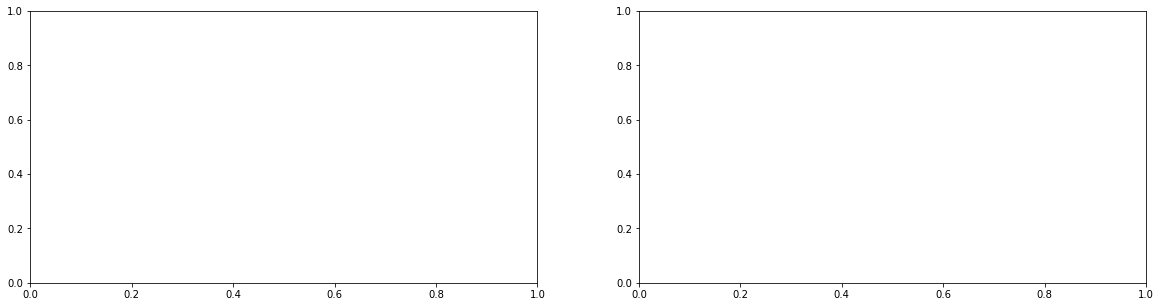

In [1]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

def collect(path, prefix, *keys):

    all_entries = os.listdir(path)
    matching_entries = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
#                 params = re.findall(r'_P(\d+)', ending)
#                 assert params, f'{entry}: trainsize p not found!'
                array = re.findall(r'_(\d+)', ending)
                matching_entries.append({
                    'ending': ending,
#                     'P': int(params[0]),
                    'seed': int(array[0])
                })
#     matching_entries.sort(key=lambda x: [x.get('P'), x.get('exp')])
    return matching_entries


def find_all(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params


def find_lowest(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params[0]


def get_loss(path, prefix):

    loss_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        loss = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                loss.append(results['best']['loss'])

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(loss)} exps. , mean loss {torch.tensor(loss).mean()}')
        loss_list.append(torch.tensor(loss))
    return loss_list


fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

768 2 1e-3 4.0 tensor(3.7787) tensor(0.0076)
768 2 1e-3 8.0 tensor(3.8730) tensor(0.0122)
768 4 3e-4 4.0 tensor(3.7167) tensor(0.0155)
768 4 3e-4 8.0 tensor(3.7731) tensor(0.0058)
768 4 1e-3 2.0 tensor(3.7711) tensor(0.0126)
768 4 1e-3 4.0 tensor(3.6964) tensor(0.0257)
768 4 1e-3 8.0 tensor(3.8099) tensor(0.0210)
768 4 3e-3 4.0 tensor(3.8826) tensor(0.0081)
768 8 1e-3 4.0 tensor(3.7383) tensor(0.0341)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

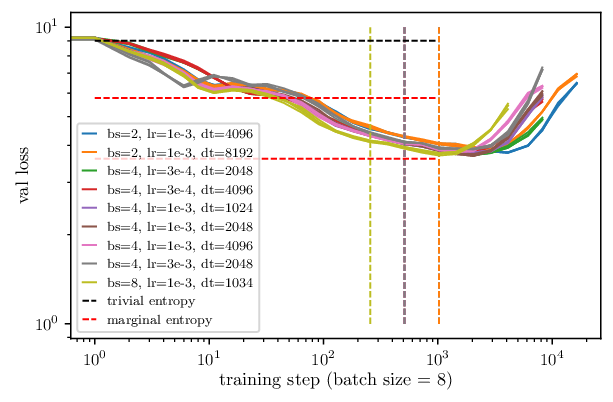

In [17]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 262144
path = f'tinystories/trained/T{T}/P{P}/'


depth = 12
de = 768
nh = 12

bs = 2
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 1034
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{18}$ : bs=4, lr=1e-3, dt=2048 (4 ep)

# $P=2^{19}$

768 4 1e-3 2.0 tensor(3.2988) tensor(0.0166)
768 4 3e-4 4.0 tensor(3.2751) tensor(0.0237)
768 4 1e-3 4.0 tensor(3.2241) tensor(0.0165)
768 4 3e-3 4.0 tensor(3.3630) tensor(0.0515)
768 4 1e-3 8.0 tensor(3.3199) tensor(0.0348)
768 8 1e-3 2.0 tensor(3.4059) tensor(0.0278)
768 8 1e-3 4.0 tensor(3.2477) tensor(0.0142)
768 8 1e-3 8.0 tensor(3.3370) tensor(0.0234)
768 8 3e-3 2.0 tensor(3.5623) tensor(0.0142)
768 8 3e-3 4.0 tensor(3.4339) tensor(0.0077)
768 16 1e-3 4.0 tensor(3.3449) tensor(0.0185)
768 16 3e-4 8.0 tensor(3.4084) tensor(0.0248)
768 16 1e-3 8.0 tensor(3.3170) tensor(0.0221)
768 16 3e-3 8.0 tensor(3.4427) tensor(0.0214)
768 16 1e-3 16.0 tensor(3.3482) tensor(0.0238)
768 32 1e-3 4.0 tensor(3.4670) tensor(0.0175)
768 32 1e-3 8.0 tensor(3.3471) tensor(0.0229)
768 32 1e-3 16.0 tensor(3.3797) tensor(0.0271)
768 64 1e-3 4.0 tensor(3.5843) tensor(0.0175)
768 64 1e-3 8.0 tensor(3.4594) tensor(0.0174)
768 64 1e-3 16.0 tensor(3.4458) tensor(0.0230)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=64$)')

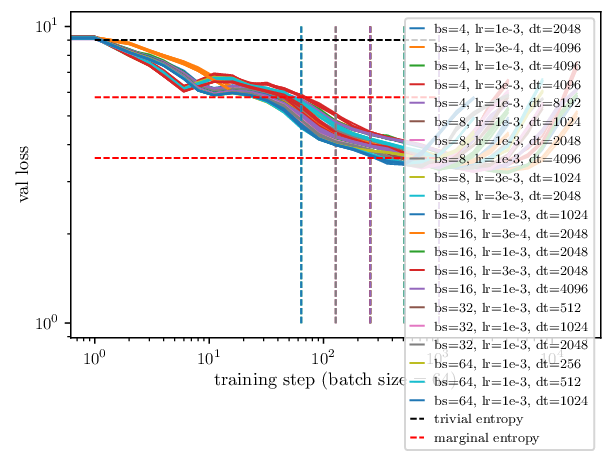

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 524288
path = f'tinystories/trained/T{T}/P{P}/'


depth = 12
de = 768
nh = 12

bs = 4
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-4'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 512
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 256
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 512
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 2 3e-4 4.0 tensor(3.2365) tensor(0.0128)
768 2 3e-4 8.0 tensor(3.3069) tensor(0.0162)
768 2 1e-3 4.0 tensor(3.2820) tensor(0.0046)
768 2 1e-3 8.0 tensor(3.2958) tensor(0.0301)
768 4 3e-4 4.0 tensor(3.2751) tensor(0.0237)
768 4 3e-4 8.0 tensor(3.3359) tensor(0.0100)
768 4 1e-3 2.0 tensor(3.2988) tensor(0.0166)
768 4 1e-3 4.0 tensor(3.2241) tensor(0.0165)
768 4 1e-3 8.0 tensor(3.3199) tensor(0.0348)
768 4 3e-3 4.0 tensor(3.3630) tensor(0.0515)
768 4 3e-3 8.0 tensor(3.3538) tensor(0.0222)
768 8 3e-4 2.0 tensor(3.5012) tensor(0.0153)
768 8 3e-4 4.0 tensor(3.3665) tensor(0.0188)
768 8 3e-4 8.0 tensor(3.3462) tensor(0.0152)
768 8 3e-4 16.0 tensor(3.3665) tensor(0.0354)
768 8 1e-3 2.0 tensor(3.4059) tensor(0.0278)
768 8 1e-3 4.0 tensor(3.2477) tensor(0.0142)
768 8 1e-3 8.0 tensor(3.3370) tensor(0.0234)
768 8 3e-3 2.0 tensor(3.5623) tensor(0.0142)
768 8 3e-3 4.0 tensor(3.4339) tensor(0.0077)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

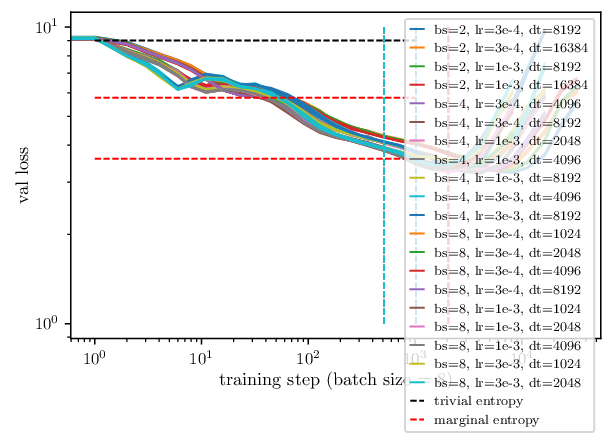

In [16]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 524288
path = f'tinystories/trained/T{T}/P{P}/'


depth = 12
de = 768
nh = 12

bs = 2
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{19}$ : bs=4, lr=1e-3, dt=4096 (4 ep)

# $P=2^{20}$

3e-4 512 tensor(3.2614) tensor(0.0113)
3e-4 1024 tensor(3.1380) tensor(0.0199)
3e-4 2048 tensor(3.1227) tensor(0.0127)
1e-3 512 tensor(3.0677) tensor(0.0179)
1e-3 1024 tensor(2.9845) tensor(0.0233)
1e-3 2048 tensor(3.0087) tensor(0.0145)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=128$)')

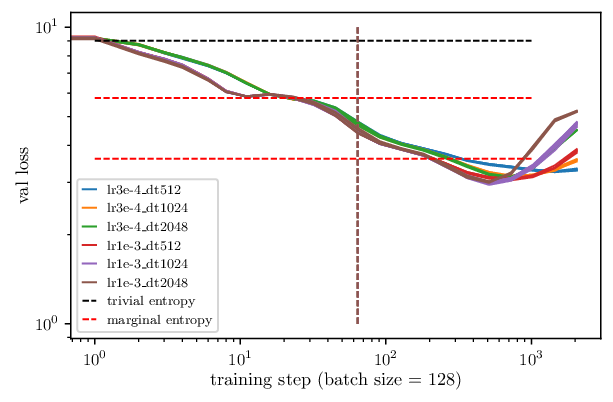

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

bs = 128
depth = 12
de = 768
nh = 12

lr = '3e-4'
dt = 512
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '3e-4'
dt = 1024
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '3e-4'
dt = 2048
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')


lr = '1e-3'
dt = 512
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
dt = 1024
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
dt = 2048
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 128 1e-3 16.0 tensor(2.9845) tensor(0.0233)
768 128 1e-3 32.0 tensor(3.0087) tensor(0.0145)
768 64 1e-3 4.0 tensor(3.0784) tensor(0.0151)
768 64 1e-3 8.0 tensor(2.9098) tensor(0.0110)
768 64 1e-3 16.0 tensor(2.9485) tensor(0.0221)
768 32 1e-3 2.0 tensor(3.0782) tensor(0.0115)
768 32 1e-3 4.0 tensor(2.9184) tensor(0.0137)
768 32 1e-3 8.0 tensor(2.9224) tensor(0.0091)
768 16 1e-3 2.0 tensor(2.9637) tensor(0.0254)
768 16 1e-3 4.0 tensor(2.8343) tensor(0.0141)
768 16 1e-3 8.0 tensor(2.9178) tensor(0.0222)
768 16 3e-3 4.0 tensor(2.9816) tensor(0.0287)
768 16 3e-4 4.0 tensor(2.9714) tensor(0.0214)
768 8 1e-3 2.0 tensor(2.8844) tensor(0.0185)
768 8 1e-3 4.0 tensor(2.8238) tensor(0.0113)
768 8 1e-3 8.0 tensor(2.9253) tensor(0.0043)
768 4 3e-4 4.0 tensor(2.8322) tensor(0.0241)
768 4 1e-3 2.0 tensor(2.8541) tensor(0.0059)
768 4 1e-3 4.0 tensor(2.8462) tensor(0.0132)
768 4 1e-3 8.0 tensor(2.9157) tensor(0.0207)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=4$)')

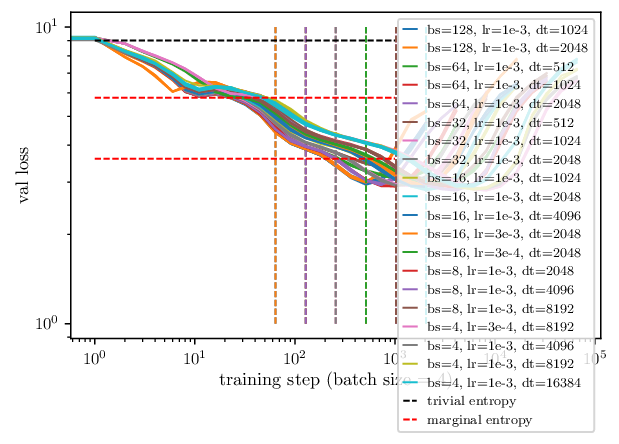

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 128
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 128
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 512
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 512
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-4'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

v

768 4 3e-4 4.0 tensor(2.8322) tensor(0.0241)
768 4 3e-4 8.0 tensor(2.9195) tensor(0.0094)
768 4 1e-3 2.0 tensor(2.8541) tensor(0.0059)
768 4 1e-3 4.0 tensor(2.8462) tensor(0.0132)
768 4 1e-3 8.0 tensor(2.9157) tensor(0.0207)
768 8 3e-4 4.0 tensor(2.8723) tensor(0.0274)
768 8 3e-4 8.0 tensor(2.9465) tensor(0.0179)
768 8 1e-3 2.0 tensor(2.8844) tensor(0.0185)
768 8 1e-3 4.0 tensor(2.8238) tensor(0.0113)
768 8 1e-3 8.0 tensor(2.9253) tensor(0.0043)
768 16 1e-3 2.0 tensor(2.9637) tensor(0.0254)
768 16 1e-3 4.0 tensor(2.8343) tensor(0.0141)
768 16 1e-3 8.0 tensor(2.9178) tensor(0.0222)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=16$)')

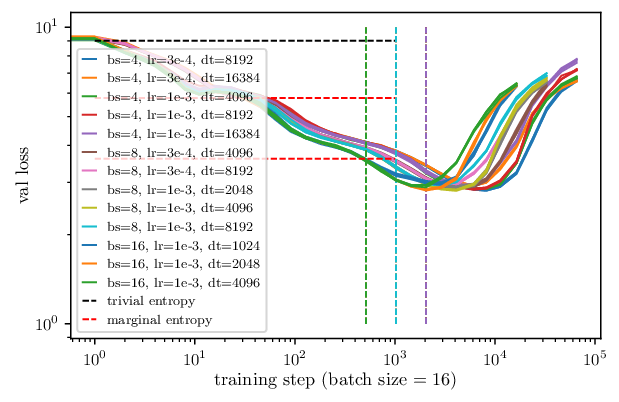

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 4
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{20}$ : bs=8, lr=1e-3, dt=4096 (4 ep)

512 64 1e-3 8.0 tensor(2.9228) tensor(0.0056)
768 64 3e-4 8.0 tensor(nan) tensor(nan)
768 64 1e-3 4.0 tensor(3.0784) tensor(0.0151)
768 64 1e-3 8.0 tensor(2.9098) tensor(0.0110)
768 64 1e-3 16.0 tensor(2.9485) tensor(0.0221)
1024 64 3e-4 8.0 tensor(3.0790) tensor(0.0076)
1024 64 1e-3 4.0 tensor(3.0591) tensor(0.0175)
1024 64 1e-3 8.0 tensor(2.9315) tensor(0.0105)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=64$)')

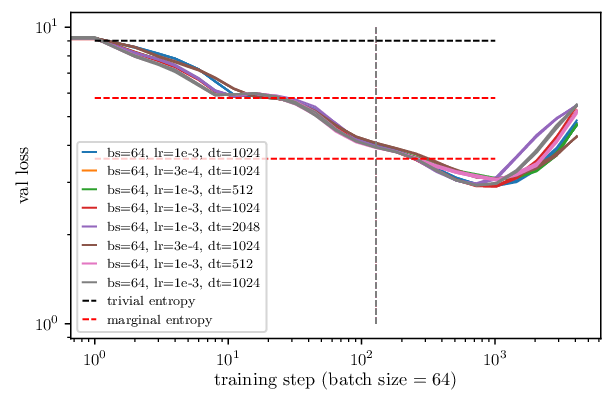

In [5]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 512
nh = 8

bs = 64
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


depth = 12
de = 768
nh = 12

bs = 64
lr = '3e-4'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 512
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

depth = 12
de = 1024
nh = 16

bs = 64
lr = '3e-4'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 512
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 64
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{21}$

32 1e-3 1024 tensor(2.6404) tensor(0.0172)
32 1e-3 2048 tensor(2.5290) tensor(0.0118)
32 1e-3 4096 tensor(2.6010) tensor(0.0102)
64 1e-3 1024 tensor(2.6258) tensor(0.0223)
64 1e-3 2048 tensor(2.5871) tensor(0.0196)
64 1e-3 4096 tensor(2.6507) tensor(0.0085)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=64$)')

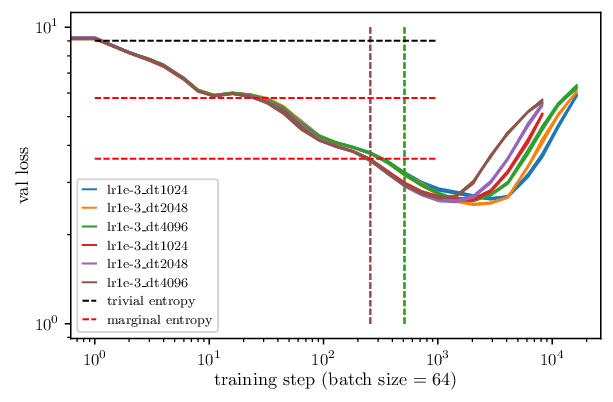

In [5]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**21
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

lr = '1e-3'
bs = 32
dt = 1024
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
bs = 32
dt = 2048
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
bs = 32
dt = 4096
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
bs = 64
dt = 1024
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
bs = 64
dt = 2048
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
bs = 64
dt = 4096
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

32 3e-4 1024 tensor(2.8050) tensor(0.0220)
32 3e-4 2048 tensor(2.6772) tensor(0.0125)
32 3e-4 4096 tensor(2.6427) tensor(0.0089)
32 1e-3 1024 tensor(2.6404) tensor(0.0172)
32 1e-3 2048 tensor(2.5290) tensor(0.0118)
32 1e-3 4096 tensor(2.6010) tensor(0.0102)
32 3e-3 1024 tensor(2.6509) tensor(0.0174)
32 3e-3 2048 tensor(2.5589) tensor(0.0153)
32 3e-3 4096 tensor(2.6086) tensor(0.0174)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

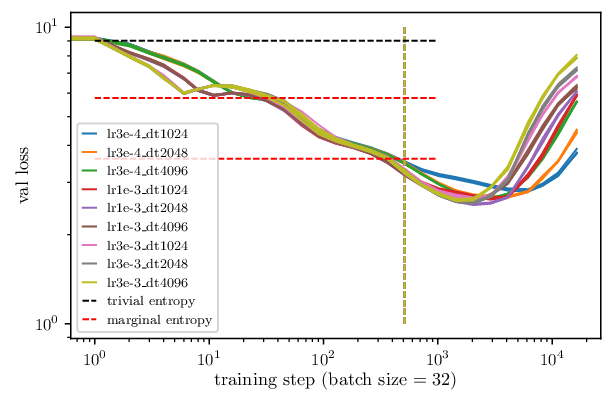

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**21
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

lr = '3e-4'
bs = 32
dt = 1024
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '3e-4'
bs = 32
dt = 2048
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '3e-4'
bs = 32
dt = 4096
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
bs = 32
dt = 1024
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
bs = 32
dt = 2048
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
bs = 32
dt = 4096
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '3e-3'
bs = 32
dt = 1024
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '3e-3'
bs = 32
dt = 2048
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '3e-3'
bs = 32
dt = 4096
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 8 3e-4 4.0 tensor(2.5153) tensor(0.0108)
768 8 1e-3 2.0 tensor(2.5627) tensor(0.0114)
768 8 1e-3 4.0 tensor(2.5220) tensor(0.0096)
768 8 1e-3 8.0 tensor(2.5982) tensor(0.0065)
768 16 3e-4 2.0 tensor(2.6956) tensor(0.0115)
768 16 3e-4 4.0 tensor(2.5626) tensor(0.0114)
768 16 3e-4 8.0 tensor(2.6143) tensor(0.0140)
768 16 1e-3 2.0 tensor(2.5680) tensor(0.0091)
768 16 1e-3 4.0 tensor(2.4986) tensor(0.0120)
768 16 1e-3 8.0 tensor(2.6012) tensor(0.0242)
768 16 3e-3 4.0 tensor(2.5876) tensor(0.0173)
768 32 1e-3 2.0 tensor(2.6404) tensor(0.0172)
768 32 1e-3 4.0 tensor(2.5290) tensor(0.0118)
768 32 1e-3 8.0 tensor(2.6010) tensor(0.0102)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

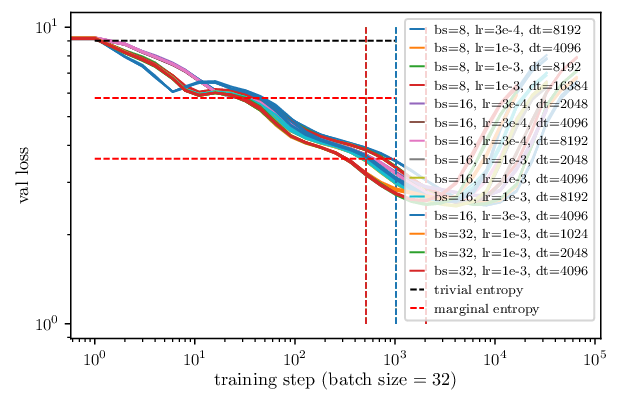

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**21
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 8
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-4'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{21}$ : bs=16, lr=1e-3, dt=4096 (4 ep)

# $P=2^{22}$

768 8 3e-4 4.0 tensor(2.2166) tensor(0.0159)
768 8 3e-4 8.0 tensor(2.2921) tensor(0.0180)
768 8 1e-3 2.0 tensor(2.2974) tensor(0.0064)
768 8 1e-3 4.0 tensor(2.2398) tensor(0.0108)
768 8 1e-3 8.0 tensor(2.2982) tensor(0.0087)
768 16 3e-4 4.0 tensor(2.2495) tensor(0.0106)
768 16 1e-3 2.0 tensor(2.2741) tensor(0.0110)
768 16 1e-3 4.0 tensor(2.2267) tensor(0.0037)
768 16 1e-3 8.0 tensor(2.2938) tensor(0.0143)
768 16 3e-3 2.0 tensor(2.3216) tensor(0.0133)
768 16 3e-3 4.0 tensor(2.2378) tensor(0.0148)
768 32 1e-3 1.0 tensor(2.3844) tensor(0.0166)
768 32 1e-3 2.0 tensor(2.3065) tensor(0.0057)
768 32 1e-3 4.0 tensor(2.2376) tensor(0.0187)
768 32 1e-3 8.0 tensor(2.3123) tensor(0.0192)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

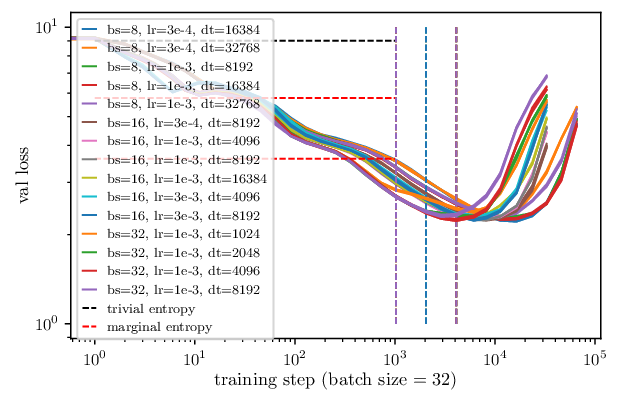

In [9]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**22
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 8
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 32
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '1e-3'
# bs = 64
# dt = 1024
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'lr{lr}_dt{dt}')


# lr = '1e-3'
# bs = 64
# dt = 2048
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'lr{lr}_dt{dt}')

# lr = '1e-3'
# bs = 64
# dt = 4096
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'lr{lr}_dt{dt}')

# lr = '1e-3'
# bs = 64
# dt = 8192
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'lr{lr}_dt{dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{22}$ : bs=8, lr=3e-4, dt=16385 (4 ep) (close to 16, 1e-3, 8192)

32 1e-3 2.0 tensor(2.3065) tensor(0.0057)
32 1e-3 4.0 tensor(2.2376) tensor(0.0187)
32 1e-3 8.0 tensor(2.3123) tensor(0.0192)
32 3e-3 2.0 tensor(2.3239) tensor(0.0107)
32 3e-3 4.0 tensor(2.2682) tensor(0.0161)
32 3e-3 8.0 tensor(2.2863) tensor(0.0100)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

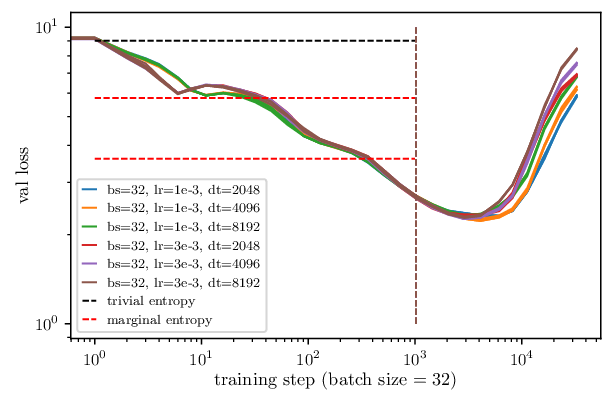

In [7]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**22
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12


lr = '1e-3'
bs = 32
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-3'
bs = 32
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-3'
bs = 32
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-3'
bs = 32
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P = 2^{23}$

8 3e-4 2.0 tensor(2.0085) tensor(0.0136)
8 3e-4 4.0 tensor(1.9791) tensor(0.0092)
8 3e-4 8.0 tensor(2.0381) tensor(0.0179)
8 1e-3 2.0 tensor(2.0468) tensor(0.0147)
8 1e-3 4.0 tensor(2.0167) tensor(0.0119)
8 1e-3 8.0 tensor(2.0666) tensor(0.0244)
16 3e-4 2.0 tensor(2.0411) tensor(0.0121)
16 3e-4 4.0 tensor(1.9895) tensor(0.0112)
16 3e-4 8.0 tensor(2.0462) tensor(0.0197)
16 1e-3 2.0 tensor(2.0458) tensor(0.0103)
16 1e-3 4.0 tensor(2.0010) tensor(0.0033)
16 1e-3 8.0 tensor(2.0445) tensor(0.0072)
32 3e-4 2.0 tensor(2.0999) tensor(0.0103)
32 3e-4 4.0 tensor(2.0224) tensor(0.0140)
32 3e-4 8.0 tensor(2.0697) tensor(0.0093)
32 1e-3 2.0 tensor(2.0452) tensor(0.0108)
32 1e-3 4.0 tensor(2.0130) tensor(0.0108)
32 1e-3 8.0 tensor(2.0540) tensor(0.0157)
64 1e-3 2.0 tensor(2.0747) tensor(0.0154)
64 1e-3 4.0 tensor(2.0110) tensor(0.0056)
64 1e-3 8.0 tensor(2.0773) tensor(0.0152)
64 3e-3 2.0 tensor(2.0820) tensor(0.0063)
64 3e-3 4.0 tensor(2.0269) tensor(0.0039)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=64$)')

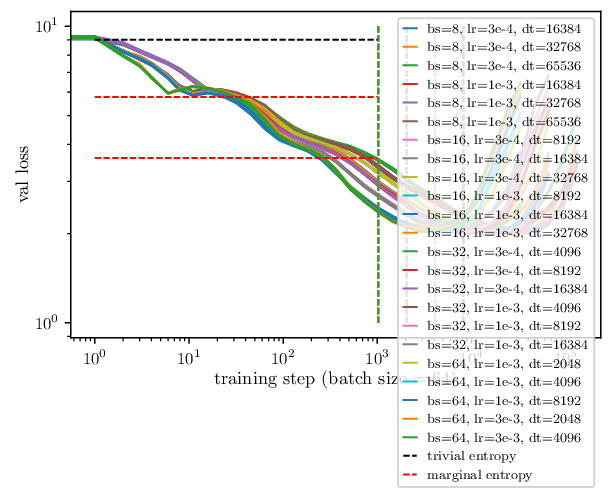

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**23
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

lr = '3e-4'
bs = 8
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 8
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 8
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 8
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 8
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 8
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 16
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 16
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 16
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 64
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 64
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 64
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-3'
bs = 64
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-3'
bs = 64
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '1e-3'
# bs = 128
# dt = 2048
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{23}$ : bs=8, lr=3e-4, dt=32768 (4 ep) (close to 16, 3e-4, 16384)

# $P=2^{24}$

128 3e-4 8.0 tensor(1.8727) tensor(0.0126)
128 1e-3 4.0 tensor(1.8401) tensor(0.0110)
64 3e-4 4.0 tensor(1.8437) tensor(0.0105)
64 1e-3 2.0 tensor(1.8541) tensor(0.0060)
64 1e-3 4.0 tensor(1.8260) tensor(0.0137)
64 1e-3 8.0 tensor(1.8634) tensor(0.0105)
64 3e-3 2.0 tensor(1.8776) tensor(0.0162)
64 3e-3 4.0 tensor(1.8335) tensor(0.0106)
768 32 3e-4 2.0 tensor(1.8674) tensor(0.0087)
768 32 3e-4 4.0 tensor(1.8028) tensor(0.0061)
768 32 3e-4 8.0 tensor(1.8625) tensor(0.0143)
768 32 1e-3 2.0 tensor(1.8621) tensor(0.0069)
768 32 1e-3 4.0 tensor(1.8193) tensor(0.0089)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

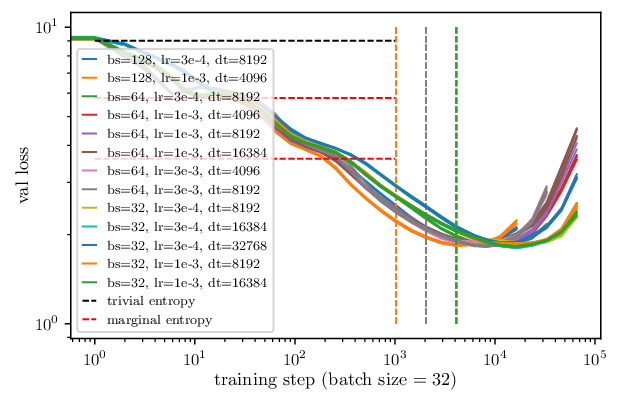

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**24
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

lr = '3e-4'
bs = 128
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 128
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 64
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 64
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 64
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 64
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-3'
bs = 64
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-3'
bs = 64
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

de = 768
nh = 12

lr = '3e-4'
bs = 32
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 8 1e-4 4.0 tensor(1.8445) tensor(0.0140)
768 8 3e-4 2.0 tensor(1.8077) tensor(0.0138)
768 8 3e-4 4.0 tensor(1.7895) tensor(0.0142)
768 8 3e-4 8.0 tensor(1.8340) tensor(0.0168)
768 16 1e-4 4.0 tensor(1.8848) tensor(0.0146)
768 16 3e-4 2.0 tensor(1.8208) tensor(0.0039)
768 16 3e-4 4.0 tensor(1.7952) tensor(0.0101)
768 16 3e-4 8.0 tensor(1.8526) tensor(0.0141)
768 16 1e-3 4.0 tensor(1.8288) tensor(0.0102)
768 32 3e-4 2.0 tensor(1.8674) tensor(0.0087)
768 32 3e-4 4.0 tensor(1.8028) tensor(0.0061)
768 32 3e-4 8.0 tensor(1.8625) tensor(0.0143)
768 32 1e-3 2.0 tensor(1.8621) tensor(0.0069)
768 32 1e-3 4.0 tensor(1.8193) tensor(0.0089)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

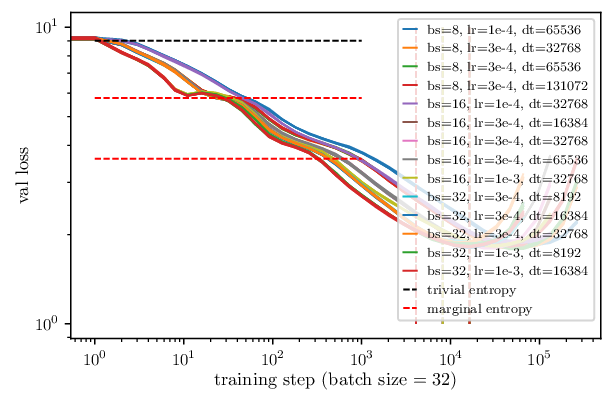

In [21]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**24
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12

de = 768
nh = 12

lr = '1e-4'
bs = 8
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 8
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 8
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 8
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-4'
bs = 16
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 16
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 32 3e-4 4.0 tensor(1.8028) tensor(0.0061)
768 32 1e-3 4.0 tensor(1.8193) tensor(0.0089)
1024 32 3e-4 2.0 tensor(1.8346) tensor(0.0089)
1024 32 3e-4 4.0 tensor(1.8011) tensor(0.0097)
1024 32 3e-4 8.0 tensor(1.8614) tensor(0.0140)
1024 64 3e-4 4.0 tensor(1.8174) tensor(0.0176)
1024 64 3e-4 8.0 tensor(1.8716) tensor(0.0089)
1024 32 1e-3 4.0 tensor(1.8245) tensor(0.0088)
1024 64 1e-3 2.0 tensor(1.8561) tensor(0.0103)
1024 64 1e-3 4.0 tensor(1.8214) tensor(0.0051)
1024 64 1e-3 8.0 tensor(1.8796) tensor(0.0095)
1024 128 1e-3 4.0 tensor(1.8329) tensor(0.0125)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=128$)')

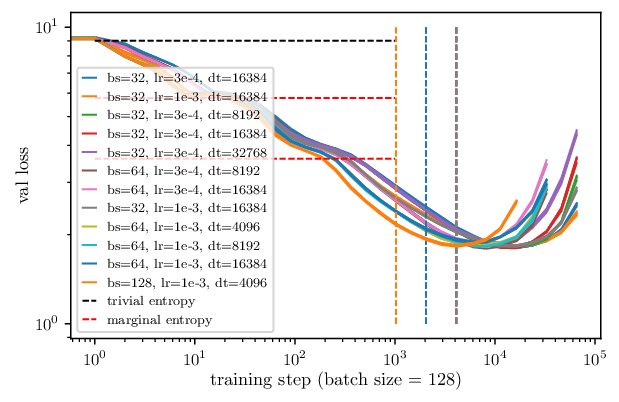

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**24
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12

de = 1024
nh = 16

lr = '3e-4'
bs = 32
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 64
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 64
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 64
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 64
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 64
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 128
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{24}$: lr=3e-4, bs=8, dt=65536 (4 ep)

In [ ]:
# TODO: de=768, try bs=4

# $P=2^{25}$

768 4 3e-4 2.0 tensor(1.6748) tensor(0.0176)
768 4 3e-4 4.0 tensor(1.6359) tensor(0.0064)
768 8 3e-4 2.0 tensor(1.6438) tensor(0.0080)
768 8 3e-4 4.0 tensor(1.6362) tensor(0.0086)
768 8 3e-4 8.0 tensor(1.6668) tensor(0.0089)
768 16 3e-4 2.0 tensor(1.6579) tensor(0.0093)
768 16 3e-4 4.0 tensor(1.6411) tensor(0.0144)
768 16 1e-3 2.0 tensor(1.7100) tensor(0.0100)
768 16 1e-3 4.0 tensor(1.6722) tensor(0.0082)
768 32 3e-4 2.0 tensor(1.6959) tensor(0.0063)
768 32 3e-4 4.0 tensor(1.6498) tensor(0.0109)
768 32 3e-4 8.0 tensor(1.6980) tensor(0.0072)
768 32 1e-3 2.0 tensor(1.7057) tensor(0.0081)
768 32 1e-3 4.0 tensor(1.6765) tensor(0.0160)
768 32 1e-3 8.0 tensor(1.6893) tensor(0.0104)


Text(0.5, 0, 'training step (batch size $=32$)')

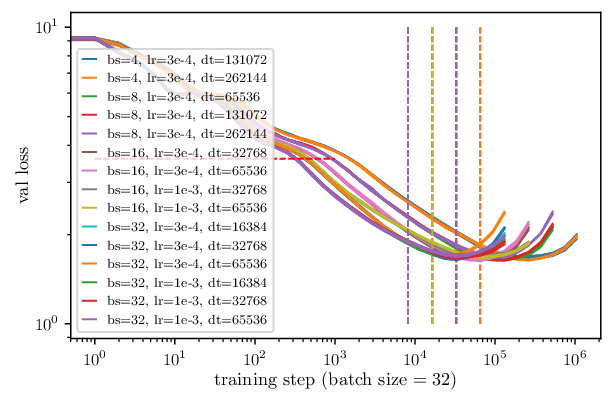

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**25
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12

# de = 1024
# nh = 16

# lr = '3e-4'
# bs = 32
# dt = 32768
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

de = 768
nh = 12

lr = '3e-4'
bs = 4
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 4
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 8
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 8
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 8
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 16
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 16
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '1e-3'
# bs = 64
# dt = 8192
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '1e-3'
# bs = 64
# dt = 16384
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '1e-3'
# bs = 64
# dt = 32768
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
# custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
# custom_labels.append(fr'trivial entropy')

# marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
# marginal = torch.from_numpy(marginal)
# marg_ent = torch.masked_select(marginal, (marginal>0))
# print(marg_ent.size())
# marg_ent = -(marg_ent*marg_ent.log()).sum()
# print(marg_ent)
# ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
# custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
# custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{25}$: lr=3e-4, bs=8, dt=131072 (4 ep)

# $P=2^{26}$

768 8 3e-4 4.0 tensor(1.5075) tensor(0.0066)
768 16 3e-4 2.0 tensor(1.5304) tensor(0.0023)
768 16 3e-4 4.0 tensor(1.5195) tensor(0.0066)
768 16 3e-4 8.0 tensor(1.5389) tensor(0.0114)
768 16 1e-3 4.0 tensor(1.5537) tensor(0.0068)
768 32 3e-4 2.0 tensor(1.5535) tensor(0.0074)
768 32 3e-4 4.0 tensor(1.5177) tensor(0.0127)
768 32 3e-4 8.0 tensor(1.5413) tensor(0.0087)
768 32 1e-3 2.0 tensor(1.5808) tensor(0.0128)
768 32 1e-3 4.0 tensor(1.5390) tensor(0.0067)
768 64 3e-4 4.0 tensor(1.5385) tensor(0.0063)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=64$)')

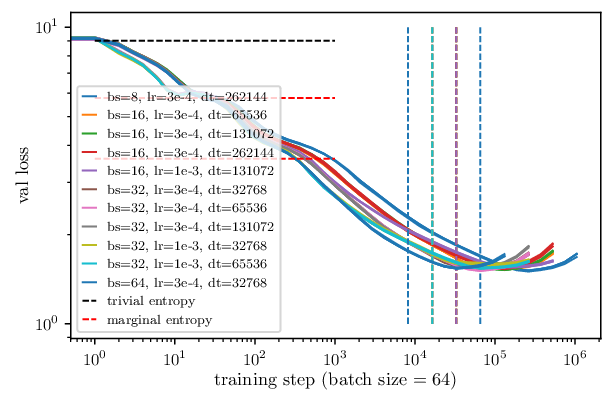

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**26
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12

de = 768
nh = 12

lr = '3e-4'
bs = 8
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 16
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 16
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


lr = '3e-4'
bs = 32
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 32
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '1e-3'
bs = 32
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

lr = '3e-4'
bs = 64
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{26}$: lr=3e-4, bs=8, dt=262144 (4 ep)

In [ ]:
# TODO: de=768, around bs=8 with lr and dt

# $P=2^{27}$

1024 8 1e-3 4.0 tensor(1.4500) tensor(0.0150)
1024 8 3e-4 4.0 tensor(1.3994) tensor(0.0085)
1024 8 3e-3 4.0 tensor(nan) tensor(nan)
1024 16 1e-4 4.0 tensor(1.4222) tensor(0.0083)
1024 16 1e-4 8.0 tensor(1.4496) tensor(0.0121)
1024 16 3e-4 4.0 tensor(1.3993) tensor(0.0070)
1024 16 3e-4 8.0 tensor(nan) tensor(nan)
1024 16 1e-3 4.0 tensor(1.4553) tensor(0.0153)
1024 16 1e-3 8.0 tensor(1.4675) tensor(0.0093)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=16$)')

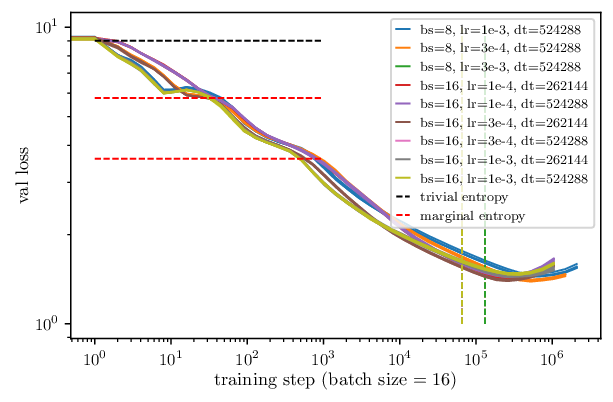

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**27
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12

de = 768
nh = 12

# lr = '3e-4'
# bs = 8
# dt = 524288
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '3e-4'
# bs = 16
# dt = 262144
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '3e-4'
# bs = 16
# dt = 524288
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '3e-4'
# bs = 32
# dt = 131072
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '3e-4'
# bs = 64
# dt = 65536
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

# lr = '3e-4'
# bs = 128
# dt = 65536
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

de = 1024
nh = 16

bs = 8
for lr in ['1e-3', '3e-4', '3e-3']:
    dt = 524288
    dt_ep = dt//(P/(bs*T))
    i += 1
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    mean_loss = []
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
        mean_loss.append(results['best']['loss'])
    #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
    print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
for lr in ['1e-4', '3e-4', '1e-3']:
    for dt in [262144, 524288]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{27}$: lr=3e-4, bs=16, dt=262144 (4 ep)

In [ ]:
# TODO: de=768, around bs=16 with lr and dt

# $P\simeq 2^{28}$

768 16 3e-4 4.0 tensor(1.3295) tensor(0.0066)
768 32 3e-4 4.0 tensor(1.3307) tensor(0.0036)
768 32 3e-4 8.0 tensor(1.3340) tensor(0.0103)
768 64 3e-4 4.0 tensor(1.3466) tensor(0.0055)
768 64 3e-4 8.0 tensor(1.3290) tensor(0.0031)
1024 8 3e-4 4.0 tensor(1.3258) tensor(0.0068)
1024 16 3e-4 4.0 tensor(1.3109) tensor(0.0065)
1024 32 3e-4 4.0 tensor(1.3213) tensor(0.0052)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=32$)')

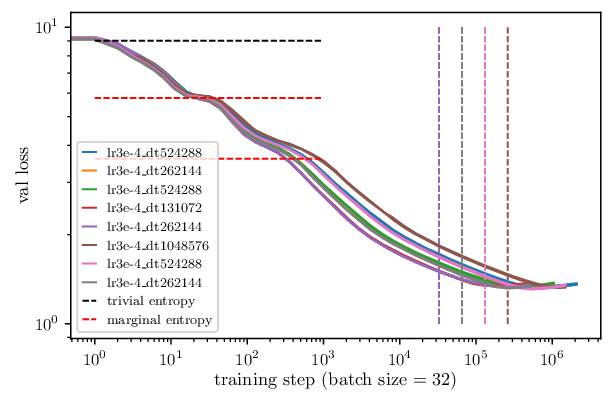

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 2**28
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 16
lr = '3e-4'
dt = 524288
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 32
lr = '3e-4'
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 32
lr = '3e-4'
dt = 524288
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 64
lr = '3e-4'
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 64
lr = '3e-4'
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

depth = 12
de = 1024
nh = 16

bs = 8
lr = '3e-4'
dt = 1048576
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 16
lr = '3e-4'
dt = 524288
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 32
lr = '3e-4'
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

# bs = 128
# lr = '3e-4'
# dt = 131072
# dt_ep = dt//(P/(bs*T))
# i += 1
# prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# mean_loss = []
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#     mean_loss.append(results['best']['loss'])
# #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
# print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C{i}'))
# custom_labels.append(fr'lr{lr}_dt{dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{28}$: de=1024, lr=3e-4, bs=16, dt=524288 (4 ep)

In [ ]:
# TODO: de=1024, around bs=16 with lr and dt

# $P\simeq 2^{29}$

1024 16 3e-4 4.0 tensor(1.2418) tensor(0.0067)
1024 32 3e-4 4.0 tensor(1.2488) tensor(0.0120)
3e-4 258400 tensor(1.2607) tensor(0.0035)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=128$)')

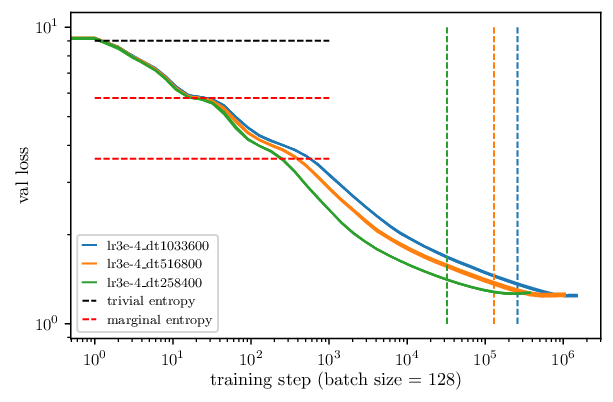

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 529203200
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 1024
nh = 16

bs = 16
lr = '3e-4'
dt = 1033600
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 32
lr = '3e-4'
dt = 516800
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 128
lr = '3e-4'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

3e-4 258400 tensor(1.2702) tensor(0.0059)
3e-4 516800 tensor(1.2712) tensor(0.0062)
1e-3 258400 tensor(1.2737) tensor(0.0108)
1e-3 516800 tensor(1.2706) tensor(0.0041)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=128$)')

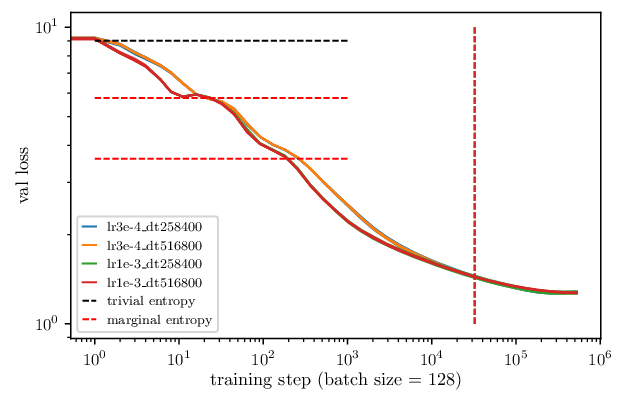

In [14]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 529203200
path = f'tinystories/trained/T{T}/P{P}/'

bs = 128
depth = 12
de = 768
nh = 12

lr = '3e-4'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 128
depth = 12
de = 768
nh = 12

lr = '3e-4'
dt = 258400*2
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 128
depth = 12
de = 768
nh = 12

lr = '1e-3'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 128
depth = 12
de = 768
nh = 12

lr = '1e-3'
dt = 258400*2
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(lr, dt, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

128 931839 1.3252884894609451 414719 524288
128 4657215 1.3034671135246754 468991 524288
128 9306033 1.3149941302835941 452607 524288
128 9608996 1.3088439144194126 414719 524288
128 7505536 1.2784346975386143 258047 524288
128 7516977 1.2639898546040058 261119 370688
128 4636813 1.2690772637724876 254975 524288
128 12899800 1.2718836180865765 247807 524288
128 14915721 1.261025756597519 436223 524288
128 9344879 1.2856190614402294 444415 524288
128 4826874 1.2709309197962284 515071 524288
128 5473977 1.279755275696516 448511 524288
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=128$)')

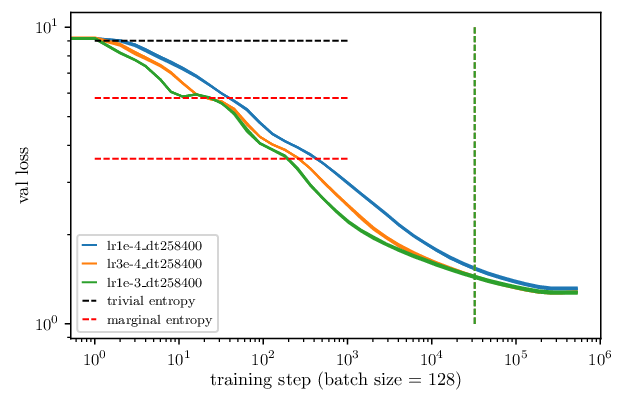

In [10]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 529203200
path = f'tinystories/trained/T{T}/P{P}/'

bs = 128
depth = 12
de = 768
nh = 12

lr = '1e-4'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '3e-4'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

lr = '1e-3'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

128 16201046 1.3191259615123272 523263 524288
128 16651410 1.3193014897406101 519167 524288
128 412148 1.3145386315882206 485375 524288
128 1163105 1.3045898638665676 524287 524288
128 7505536 1.2784346975386143 258047 524288
128 7516977 1.2639898546040058 261119 370688
128 4636813 1.2690772637724876 254975 524288
128 12899800 1.2718836180865765 247807 524288
128 12253519 1.261955164372921 226303 370688
128 3453371 1.2630249708890915 222207 370688
128 4063998 1.2683491706848145 234495 370688
128 3965137 1.259771455079317 222207 370688
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=128$)')

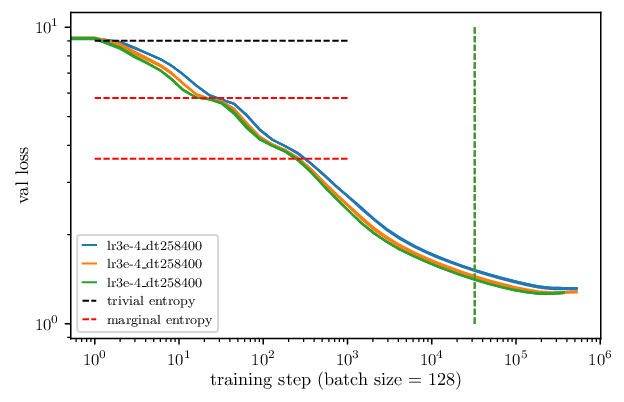

In [20]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 529203200
path = f'tinystories/trained/T{T}/P{P}/'

bs = 128
depth = 12
de = 512
nh = 8

lr = '3e-4'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 128
depth = 12
de = 768
nh = 12

lr = '3e-4'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

bs = 128
depth = 12
de = 1024
nh = 16

lr = '3e-4'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# ALLSTARS

In [1]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1
T = 128

depth = 12
de = 768
nh = 12

P = 2**18
path = f'tinystories/trained/T{T}/P{P}/'
bs = 4
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 2**19
path = f'tinystories/trained/T{T}/P{P}/'
bs = 4
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 2**20
path = f'tinystories/trained/T{T}/P{P}/'
bs = 8
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 2**21
path = f'tinystories/trained/T{T}/P{P}/'
bs = 16
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 2**22
path = f'tinystories/trained/T{T}/P{P}/'
bs = 8
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 2**23
path = f'tinystories/trained/T{T}/P{P}/'
lr = '3e-4'
bs = 8
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 2**24
path = f'tinystories/trained/T{T}/P{P}/'
lr = '3e-4'
bs = 8
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 2**25
path = f'tinystories/trained/T{T}/P{P}/'
lr = '3e-4'
bs = 8
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 2**26
path = f'tinystories/trained/T{T}/P{P}/'
lr = '3e-4'
bs = 32
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 529203200
path = f'tinystories/trained/T{T}/P{P}/'

bs = 128
depth = 12
de = 768
nh = 12

lr = '1e-3'
dt = 258400
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'lr{lr}_dt{dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

NameError: name 'matplotlib' is not defined

In [18]:
258400/(529203200/(128*128)), 512/(1048576/(128*128))

(8.0, 8.0)

In [ ]:
depth = 12
de = 1024
nh = 16
lr = '3e-4'
prefix = f'tinystories.BPE8192_T128_P529203200_d{depth}_demb{de}_nh{nh}_bs128_lr{lr}_wt8_dt258400'

collection = collect( 'tinystories/trained/', prefix)
print(collection)

In [ ]:
# filename = f'tinystories.BPE8192_T128_P134217728_d8_demb768_nh12_bs128_lr3e-4_wt8_dt16384_13116439.pt'
# results = torch.load('results/'+filename)

# print(results.keys())
# print(results['config'])
# print(results['config'].seed_model)

## PLOT validation loss vs time

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})

fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)

filename = f'tinystories.BPE8192_T128_P134217728_d8_demb768_nh12_bs128_lr3e-4_wt8_dt16384_13116439.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C0', label='d_emb=768, dt=2 epochs')
print(results.keys(), min([d['val_loss'] for d in dynamics]))


filename = f'tinystories.BPE8192_T128_P134217728_d8_demb768_nh12_bs128_lr3e-4_wt8_dt32768_9589644.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C1', label='dt *= 2')
print(results.keys(), min([d['val_loss'] for d in dynamics]))


filename = f'tinystories.BPE8192_T128_P134217728_d8_demb768_nh12_bs128_lr3e-4_wt8_dt65536_10436889.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C2', label=f'dt *= 4')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

# filename = f'tinystories.BPE8192_T128_P134217728_d8_demb1024_nh16_bs128_lr3e-4_wt8_dt65536_12732223.pt'
# results = torch.load('results/'+filename)
# dynamics = results['dynamics']
# print(results.keys())

# ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C3', label=f'dt *= 4, d_emb += 2**.5')


# filename = f'tinystories.BPE8192_T128_P134217728_d12_demb768_nh12_bs128_lr3e-4_wt8_dt65536_5738487.pt'
# results = torch.load('results/'+filename)
# dynamics = results['dynamics']
# print(results.keys())

# ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C4', label=f'dt *= 4, depth 12')


ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

### $P=2^{27}$, compare d_emb size

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})

fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)

filename = f'tinystories.BPE8192_T128_P134217728_d8_demb768_nh12_bs128_lr3e-4_wt8_dt65536_10436889.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C0', label=f'd_emb={768}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

filename = f'tinystories.BPE8192_T128_P134217728_d8_demb512_nh8_bs128_lr3e-4_wt8_dt16384_10682635.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C1', label=f'd_emb={512}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

filename = f'tinystories.BPE8192_T128_P134217728_d8_demb384_nh6_bs128_lr3e-4_wt8_dt16384_16668486.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C2', label=f'd_emb={384}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

filename = f'tinystories.BPE8192_T128_P134217728_d8_demb1024_nh16_bs128_lr3e-4_wt8_dt65536_12732223.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C3', label=f'd_emb={1024}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

filename = f'tinystories.BPE8192_T128_P134217728_d12_demb768_nh12_bs128_lr3e-4_wt8_dt65536_5738487.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C4', label=f'depth 12')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

filename = f'tinystories.BPE8192_T128_P134217728_d8_demb768_nh12_bs128_lr3e-4_wt8_dt65536_1497795.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C5')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

ax.legend()
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

### $P=2^{28}$, compare d_emb size

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})

fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)

filename = f'tinystories.BPE8192_T128_P268435456_d8_demb768_nh12_bs128_lr3e-4_wt8_dt131072_12716847.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C0', label=f'd_emb={768}, depth={8}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

filename = f'tinystories.BPE8192_T128_P268435456_d8_demb1024_nh16_bs128_lr3e-4_wt8_dt131072_2559164.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C1', label=f'd_emb={1024}, depth={8}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

filename = f'tinystories.BPE8192_T128_P268435456_d10_demb768_nh12_bs128_lr3e-4_wt8_dt131072_8416914.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C2', label=f'd_emb={768}, depth={10}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))


filename = f'tinystories.BPE8192_T128_P268435456_d10_demb768_nh12_bs128_lr3e-4_wt8_dt131072_15866582.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C2', linestyle='dashed', label=f'd_emb={768}, depth={10}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))


filename = f'tinystories.BPE8192_T128_P268435456_d12_demb768_nh12_bs128_lr3e-4_wt8_dt131072_5267093.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C4', label=f'd_emb={768}, depth={12}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

filename = f'tinystories.BPE8192_T128_P268435456_d12_demb1024_nh16_bs128_lr3e-4_wt8_dt131072_8743911.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C5', label=f'd_emb={1024}, depth={12}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))

ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

### $P \simeq 2^{29}$ (maximum), compare depth

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})

fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)

filename = f'tinystories.BPE8192_T128_P529203200_d8_demb768_nh12_bs128_lr3e-4_wt8_dt258400_4287038.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C0', label=f'd_emb={768}, depth {8}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))
# print([d['t'] for d in dynamics])

filename = f'tinystories.BPE8192_T128_P529203200_d10_demb768_nh12_bs128_lr3e-4_wt8_dt258400_8723821.pt'
results = torch.load('tinystories/trained/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C1', label=f'd_emb={768}, depth {10}')
print(results.keys(), min([d['val_loss'] for d in dynamics]))
# print([d['t'] for d in dynamics])

depth = 12
de = 768
nh = 12
lr = '3e-4'
prefix = f'tinystories.BPE8192_T128_P529203200_d{depth}_demb{de}_nh{nh}_bs128_lr{lr}_wt8_dt258400'
collection = collect( 'tinystories/trained/', prefix)
for entry in collection:

    results = torch.load('results/'+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C2', label=f'd_emb={768}, depth {12}')
    print(entry['seed'], min([d['val_loss'] for d in dynamics]))


ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

### $P \simeq 2^{29}$ (maximum), compare embedding size

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})

fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)

depth = 12
de = 512
nh = 8
lr = '3e-4'
prefix = f'tinystories.BPE8192_T128_P529203200_d{depth}_demb{de}_nh{nh}_bs128_lr{lr}_wt8_dt258400'
collection = collect( 'tinystories/trained/', prefix)
for entry in collection:

    results = torch.load('results/'+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C0', label=f'd_emb={de}, depth {depth}')
    print(de, depth, entry['seed'], min([d['val_loss'] for d in dynamics]))


depth = 12
de = 768
nh = 12
lr = '3e-4'
prefix = f'tinystories.BPE8192_T128_P529203200_d{depth}_demb{de}_nh{nh}_bs128_lr{lr}_wt8_dt258400'
collection = collect( 'tinystories/trained/', prefix)
for entry in collection:

    results = torch.load('results/'+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C1', label=f'd_emb={de}, depth {depth}')
    print(de, depth, entry['seed'], min([d['val_loss'] for d in dynamics]))


depth = 12
de = 1024
nh = 16
lr = '3e-4'
prefix = f'tinystories.BPE8192_T128_P529203200_d{depth}_demb{de}_nh{nh}_bs128_lr{lr}_wt8_dt258400'
collection = collect( 'tinystories/trained/', prefix)
for entry in collection:

    results = torch.load('results/'+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C2', label=f'd_emb={de}, depth {depth}')
    print(de, depth, entry['seed'], min([d['val_loss'] for d in dynamics]))


ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

### $P \simeq 2^{29}$ (maximum), compare learning rate

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})

fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)

depth = 12
de = 768
nh = 12
lr = '1e-3'
prefix = f'tinystories.BPE8192_T128_P529203200_d{depth}_demb{de}_nh{nh}_bs128_lr{lr}_wt8_dt258400'
collection = collect( 'tinystories/trained/', prefix)
for entry in collection:

    results = torch.load('results/'+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C0', label=f'lr={lr}')
    print(lr, entry['seed'], min([d['val_loss'] for d in dynamics]))


depth = 12
de = 768
nh = 12
lr = '3e-4'
prefix = f'tinystories.BPE8192_T128_P529203200_d{depth}_demb{de}_nh{nh}_bs128_lr{lr}_wt8_dt258400'
collection = collect( 'tinystories/trained/', prefix)
for entry in collection:

    results = torch.load('results/'+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C1', label=f'lr={lr}')
    print(lr, entry['seed'], min([d['val_loss'] for d in dynamics]))

depth = 12
de = 768
nh = 12
lr = '1e-4'
prefix = f'tinystories.BPE8192_T128_P529203200_d{depth}_demb{de}_nh{nh}_bs128_lr{lr}_wt8_dt258400'
collection = collect( 'tinystories/trained/', prefix)
for entry in collection:

    results = torch.load('results/'+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C2', label=f'lr={lr}')
    print(lr, entry['seed'], min([d['val_loss'] for d in dynamics]))


ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


path = 'tinystories/trained/'
vocab_size = 8192
split='train'

T = 512
bs = 128
depth = 12
de = 768
nh = 12
lr = '3e-4'

for i,P in enumerate([ 2**20, 2**22, 2**23, 2**24, 2**25, 2**26, 529203200]): 

    dt = (P//(T*bs))*8
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}', label=f'P={P}, T={T}')
        print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'$P={P}$, $T={T}$')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

fig.tight_layout()

### $T=16$, compare number of data

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


path = 'tinystories/trained/'
vocab_size = 8192
split='train'

T = 16
bs = 128
depth = 12
de = 768
nh = 12
lr = '3e-4'

for i,P in enumerate([2**15, 2**16, 2**17, 2**18, 2**19, 2**20, 2**21, 2**22, 2**23, 2**24,2**25, 2**26, 529203200]): 

    dt = (P//(T*bs))*8
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}', label=f'P={P}, T={T}')
        print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'$P={P}$, $T={T}$')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

fig.tight_layout()

In [ ]:
path = 'tinystories/trained/'
vocab_size = 8192
split='train'
T = 16

error_list = get_loss(path, f'tinystories.BPE8192_T{T}')
p_list = find_all(path, f'tinystories.BPE8192_T{T}', 'P')

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 2, figsize=(2*5.7, 1*3.6), dpi=120)

emp_limit_loss = 1.5

ax[0].errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=f'C0', marker='.')
ax[1].errorbar(p_list, [err.mean()-emp_limit_loss for err in error_list], yerr=[err.std() for err in error_list], color=f'C0', marker='.')

ax[0].plot([1e5,1e8],[10*1e5**-(.33/1.8),10*1e8**-(.33/1.8)],'k--')
ax[1].plot([1e5,1e8],[10*1e5**-(.33/1.8),10*1e8**-(.33/1.8)],'k--')


ax[0].legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax[0].set_xscale('log')
# ax.set_ylim(1.,5.)
ax[0].set_yscale('log')
# ax.set_xlim(1,16)
ax[1].set_xscale('log')
# ax.set_ylim(1.,5.)
ax[1].set_yscale('log')


ax[0].set_ylabel(fr'AR loss', fontsize=11)
ax[0].set_xlabel(fr'training set size $P$', fontsize=11)

fig.tight_layout()

In [ ]:
def get_ngrams(nmax, path, prefix):

    ngrams_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        ngrams = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                ngram = torch.zeros(nmax)
                for n in range(nmax):
                    ngram[n] = min([d['ngram_loss'][n] for d in results['dynamics']])
                ngrams.append(ngram)

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(ngrams)} exps. , mean 1-gram {torch.tensor([x[0] for x in ngrams]).mean()}')
        ngrams_list.append(torch.stack(tuple(ngrams)))
    return ngrams_list

ngrams_list = get_ngrams( T, path, f'tinystories.BPE8192_T{T}')

In [ ]:
print(ngrams_list[0].size())

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)

ax.plot([p for p in p_list], [loss.mean() for loss in error_list], 'r--')

for i in range(16):

    ax.plot([p for p in p_list], [loss[:,i].mean() for loss in ngrams_list], f'C{i}',  marker='.', label=f'n={i+1}')

ax.plot([4e4,4e6],[15*4e4**-.13,15*4e6**-.13],'k--')

ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'n-gram loss', fontsize=11)
ax.set_xlabel(fr'training set size $P$', fontsize=11)

fig.tight_layout()

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)

beta = 0.88
alpha = 0.13

# ax.plot([p for p in p_list], [loss.mean() for loss in error_list], 'r--')

for i in range(16):

    ax.plot([p/(i+1)**(2*beta) for p in p_list], [loss[:,i].mean()*(i+1)**(alpha*2*beta) for loss in ngrams_list], f'C{i}',  marker='.', label=f'n={i+1}')

# ax.plot([4e4,4e6],[15*4e4**-.13,15*4e6**-.13],'k--')

ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'n-gram loss', fontsize=11)
ax.set_xlabel(fr'training set size $P$', fontsize=11)

fig.tight_layout()

In [ ]:
fig.savefig(path+f'ngram-losses-vs-num-data_T16_d12_demb768_nh12_bs128_lr3e-4.pdf')

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)

# ax.plot([p for p in p_list], [loss.mean() for loss in error_list], 'k--')

for i,p in enumerate(p_list):

    ax.plot([t for t in range(1,16+1)], ngrams_list[i].mean(dim=0), f'C{i}',  marker='.', label=f'P={p}')


alpha = 0.33
scale = ngrams_list[-1][:,0].mean()
ax.plot(torch.arange(1,T+1), [scale*n**(-alpha) for n in range(1,T+1)], 'k--')


ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'n-gram losses loss', fontsize=11)
ax.set_xlabel(fr'$n$', fontsize=11)

fig.tight_layout()

In [ ]:
fig.savefig(path+f'ngram-losses-vs-n_T128_d12_demb768_nh12_bs128_lr3e-4.pdf')

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


path = 'tinystories/trained/'
vocab_size = 8192
split = 'train'

T = 512
bs = 32
depth = 12
de = 768
nh = 12
lr = '3e-4'

n=16

for i,P in enumerate([2**20, 2**21, 2**22, 2**23, 2**24, 2**25, 2**26, 2**27, 2**28, 529203200]): 

    dt = (P//(T*bs))*8
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}', label=f'P={P}, T={T}')
        print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'$P={P}$, $T={T}$')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'{n}-gram loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

fig.tight_layout()

In [ ]:
path = 'tinystories/trained/'
vocab_size = 8192
split='train'
T = 512

error_list = get_loss(path, f'tinystories.BPE8192_T{T}')
p_list = find_all(path, f'tinystories.BPE8192_T{T}', 'P')

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 2, figsize=(2*5.7, 1*3.6), dpi=120)

emp_limit_loss = 0.5

ax[0].errorbar([p for p in p_list], [loss.mean() for loss in error_list], yerr=[loss.std() for loss in error_list], color=f'C0', marker='.')
ax[1].errorbar(p_list, [err.mean()-emp_limit_loss for err in error_list], yerr=[err.std() for err in error_list], color=f'C0', marker='.')

ax[0].plot([1e5,1e8],[10*1e5**-(.33/1.8),10*1e8**-(.33/1.8)],'k--')
ax[1].plot([1e5,1e8],[10*1e5**-(.33/1.8),10*1e8**-(.33/1.8)],'k--')


ax[0].legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax[0].set_xscale('log')
# ax.set_ylim(1.,5.)
ax[0].set_yscale('log')
# ax.set_xlim(1,16)
ax[1].set_xscale('log')
# ax.set_ylim(1.,5.)
ax[1].set_yscale('log')


ax[0].set_ylabel(fr'AR loss', fontsize=11)
ax[0].set_xlabel(fr'training set size $P$', fontsize=11)

fig.tight_layout()

In [ ]:
def get_ngrams(nmax, path, prefix):

    ngrams_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        ngrams = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                ngram = torch.zeros(nmax)
                for n in range(nmax):
                    ngram[n] = min([d['ngram_loss'][n] for d in results['dynamics']])
                ngrams.append(ngram)

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(ngrams)} exps. , mean 1-gram {torch.tensor([x[0] for x in ngrams]).mean()}')
        ngrams_list.append(torch.stack(tuple(ngrams)))
    return ngrams_list

ngrams_list = get_ngrams( T, path, f'tinystories.BPE8192_T{T}')

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)

ax.plot([p for p in p_list], [loss.mean() for loss in error_list], 'r--')

for i in [2**exp-1 for exp in range(10)]:

    ax.plot([p for p in p_list], [loss[:,i].mean() for loss in ngrams_list], f'C{i}',  marker='.', label=f'n={i+1}')

# ax.plot([4e4,4e6],[15*4e4**-.13,15*4e6**-.13],'k--')

ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'n-gram loss', fontsize=11)
ax.set_xlabel(fr'training set size $P$', fontsize=11)

fig.tight_layout()

### $P \simeq 2^{29}$ (maximum), compare context size

In [ ]:
# %%time
# ## Compute 0-gram cross entropy
# print(device)
# vocab_size = 8192
# split = 'train'

# ## 1.1 Extract the empirical 0-gram (marginal probability)
# corpus = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}.npy")
# corpus = torch.tensor(corpus).to(device)
# corpus_len = corpus.size(0)
# print(corpus_len)

# batch_size = 32768
# num_batches = corpus_len//batch_size

# marginal = torch.zeros(
#     (vocab_size), device=device
# )

# count = 0
# for batch_idx in range(num_batches):

#     batch = F.one_hot(
#         corpus[batch_size*batch_idx:batch_size*(batch_idx+1)].long(), num_classes=vocab_size
#     ).float()
#     marginal += batch.sum(dim=0)
#     count += batch.size(0)

# batch = F.one_hot(
#     corpus[batch_size*num_batches:].long(), num_classes=vocab_size
# ).float()
# marginal += batch.sum(dim=0)
# count += batch.size(0)

# print(count)
# marginal /= count
# print(marginal.size())
# # batch = corpus[current:]
# # print(batch.size(0), current + batch.size(0), corpus_len)
# np.save("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy", np.array(marginal.cpu(), dtype=np.float32))

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


path = 'tinystories/trained/'
vocab_size = 8192
split = 'train'

P = 529203200
bs = 128
depth = 12
de = 768
nh = 12
lr = '3e-4'

for i,T in enumerate([ 2, 4, 8, 16]): 

    dt = (P//(T*bs))*8
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P529203200_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}', label=f'P={P}, T={T}')
        print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'$P={P}$, $T={T}$')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

fig.tight_layout()

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


path = 'tinystories/trained/'
n = 512

P = 529203200
T = 512
bs = 128
dt = (P//(T*bs))*8
depth = 12
de = 768
nh = 12
lr = '3e-4'
prefix = f'tinystories.BPE8192_T{T}_P529203200_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C0', label=f'P={P}, T={T}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C0', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C0'))
custom_labels.append(fr'$P={P}$, $T={T}$, $B={bs}$')

P = 529203200
T = 512
bs = 64
dt = (P//(T*bs))*8
depth = 12
de = 768
nh = 12
lr = '3e-4'
prefix = f'tinystories.BPE8192_T{T}_P529203200_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C1', label=f'P={P}, T={T}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C1', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C1'))
custom_labels.append(fr'$P={P}$, $T={T}$, $B={bs}$')

P = 529203200
T = 512
bs = 32
dt = (P//(T*bs))*8
depth = 12
de = 768
nh = 12
lr = '3e-4'
prefix = f'tinystories.BPE8192_T{T}_P529203200_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C2', label=f'P={P}, T={T}')
    print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C2', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C2'))
custom_labels.append(fr'$P={P}$, $T={T}$, $B={bs}$')

# P = 529203200
# T = 128
# bs = 128
# dt = (P//(T*bs))*8
# depth = 12
# de = 768
# nh = 12
# lr = '3e-4'
# prefix = f'tinystories.BPE8192_T{T}_P529203200_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
# collection = collect( path, prefix)
# for entry in collection:

#     results = torch.load(path+prefix+entry['ending'])
#     dynamics = results['dynamics']
#     ax.plot([d['t'] for d in dynamics], [d['ngram_loss'][n-1] for d in dynamics], f'C3', label=f'P={P}, T={T}')
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
# ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C3', linestyle='dashed')
# custom_lines.append(Line2D([0], [0], color=f'C3'))
# custom_labels.append(fr'$P={P}$, $T={T}$, $B={bs}$')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'valid loss', fontsize=11)
ax.set_xlabel(fr'training step', fontsize=11)

fig.tight_layout()

In [ ]:
2**26

In [ ]:
fig.savefig(path+f'loss-vs-time_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}.pdf')

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


path = 'tinystories/trained/'
vocab_size = 8192
split = 'train'

n = 16
P = 529203200
bs = 128
depth = 12
de = 768
nh = 12
lr = '3e-4'

for i,T in enumerate([16, 32, 64, 128, 256, 512]): 

    dt = (P//(T*bs))*8
    prefix = f'tinystories.BPE{vocab_size}_T{T}_P529203200_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
    collection = collect( path, prefix)
    for entry in collection:

        results = torch.load(path+prefix+entry['ending'])
        dynamics = results['dynamics']
        ax.plot([d['t'] for d in dynamics], [d['ngram_loss'][n-1] for d in dynamics], f'C{i}', label=f'P={P}, T={T}')
        print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['step'], dynamics[-1]['t'])
    ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=f'C{i}'))
    custom_labels.append(fr'$P={P}$, $T={T}$')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'{n}-gram loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $=128$)', fontsize=11)

fig.tight_layout()

In [ ]:
fig.savefig(path+f'{n}-loss-vs-time_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}.pdf')

### n-gram analysis, $T=16$

In [ ]:
path = 'tinystories/trained/'
filename = f'tinystories.BPE8192_T16_P262144_d12_demb768_nh12_bs128_lr3e-4_wt8_dt1024_14372969.pt'
results = torch.load(path+filename)
dynamics = results['dynamics']

print([d['t'] for d in dynamics])
print(results['best']['step'], results['best']['loss'])

In [ ]:
filename = f'tinystories.BPE8192_T16_P262144_d12_demb768_nh12_bs128_lr3e-4_wt8_dt1024_14372969.pt'
results = torch.load(path+filename)
dynamics = results['dynamics']

fig, ax = plt.subplots(1, 2, figsize=(13,5))

for time in [1, 2, 3, 4, 6, 8, 11, 16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 1024, 1448, 2048]:

    selected = list(filter(lambda x: x['t'] == time, dynamics))
    result = selected[0]
    ax[0].plot(torch.arange(1,result['ngram_loss'].size(0)+1), result['ngram_loss'], label=f't={time}')

alpha = 0.33
scale = result['ngram_loss'][0]
ax[0].plot(torch.arange(1,result['ngram_loss'].size(0)+1), [scale*n**(-alpha) for n in range(1,result['ngram_loss'].size(0)+1)], 'k--')

for n in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]:


    ax[1].plot([d['t'] for d in dynamics], [d['ngram_loss'][n-1] for d in dynamics], label=f'n={n}')

ax[1].plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], 'k--', label='valid loss')
# ax[1].plot([1e1,1e3],[10*1e1**(-.25),10*1e3**(-.25)],'r--')


ax[0].legend()
ax[0].set_xlim(1,512)
ax[0].set_xscale('log')
ax[0].set_xlabel(r'$n$', fontsize=15)
ax[0].set_ylim(1.,5.)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\mathcal{L}_n(t)$', fontsize=15)

ax[1].legend()
ax[1].set_xlim(1e0,1e6)
ax[1].set_xscale('log')
ax[1].set_xlabel(r'$t$', fontsize=15)
ax[1].set_ylim(1.,10.)
ax[1].set_yscale('log')
# ax[1].set_ylabel(r'$\mathcal{L}_n(t)$', fontsize=15)

fig.tight_layout()

In [ ]:
fig.savefig(path+f'ngram-losses_T16_P529203200_d12_demb768_nh12_bs128_lr3e-4_wt8_dt2067200_10995060.pdf')

### n-gram analysis, $T=128$

In [ ]:
path = 'tinystories/trained/'
filename = f'tinystories.BPE8192_T128_P529203200_d12_demb768_nh12_bs128_lr3e-4_wt8_dt258400_12899800.pt'
results = torch.load(path+filename)
dynamics = results['dynamics']

print([d['t'] for d in dynamics])
print(results['best']['step'], results['best']['loss'])

In [ ]:
filename = f'tinystories.BPE8192_T128_P529203200_d12_demb768_nh12_bs128_lr3e-4_wt8_dt258400_12899800.pt'
results = torch.load(path+filename)
dynamics = results['dynamics']

fig, ax = plt.subplots(1, 2, figsize=(13,5))

for time in [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288]:

    selected = list(filter(lambda x: x['t'] == time, dynamics))
    result = selected[0]
    ax[0].plot(torch.arange(1,result['ngram_loss'].size(0)+1), result['ngram_loss'], label=f't={time}')

alpha = 0.33
scale = result['ngram_loss'][0]
ax[0].plot(torch.arange(1,result['ngram_loss'].size(0)+1), [scale*n**(-alpha) for n in range(1,result['ngram_loss'].size(0)+1)], 'k--')

for i_n, n in enumerate([1,2,4,8,12,16,24,32,48,64,128]):

    ax[1].plot([d['t'] for d in dynamics], [d['ngram_loss'][n-1] for d in dynamics], f'C{i_n}', label=f'n={n}')

ax[1].plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], 'k--', label='valid loss')
# ax[1].plot([1e1,1e3],[10*1e1**(-.25),10*1e3**(-.25)],'r--')

# filename2 = f'tinystories.BPE8192_T16_P529203200_d12_demb768_nh12_bs128_lr3e-4_wt8_dt2067200_10995060.pt'
# results2 = torch.load('results/'+filename2)
# dynamics2 = results2['dynamics']
# for i, n in enumerate([1,2,4,8,12,16]):

#     ax[1].plot([d['t'] for d in dynamics2], [d['ngram_loss'][n-1] for d in dynamics2], f'C{i}', linestyle='dashed')


ax[0].legend()
ax[0].set_xlim(1,512)
ax[0].set_xscale('log')
ax[0].set_xlabel(r'$n$', fontsize=15)
ax[0].set_ylim(1.,5.)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\mathcal{L}_n(t)$', fontsize=15)

ax[1].legend()
ax[1].set_xlim(1e0,1e6)
ax[1].set_xscale('log')
ax[1].set_xlabel(r'$t$', fontsize=15)
ax[1].set_ylim(1.,10.)
ax[1].set_yscale('log')
# ax[1].set_ylabel(r'$\mathcal{L}_n(t)$', fontsize=15)

fig.tight_layout()

In [ ]:
fig.savefig(path+f'ngram-losses_T128_P529203200_d12_demb768_nh12_bs128_lr3e-4_wt8_dt258400_12899800.pdf')

### n-gram analysis, $T=512$

In [ ]:
path = "tinystories/trained/"
filename = f'tinystories.BPE8192_T512_P529203200_d12_demb768_nh12_bs64_lr3e-4_wt8_dt129200_12330584.pt'
results = torch.load(path+filename)
dynamics = results['dynamics']

print([d['t'] for d in dynamics])
print(results['best']['step'], results['best']['loss'])

esempio = torch.stack(tuple([torch.tensor([d['ngram_loss'][n-1] for d in dynamics]) for n in range(1,17)]))
print(esempio.mean(dim=0))

In [ ]:
filename = f'tinystories.BPE8192_T512_P529203200_d12_demb768_nh12_bs64_lr3e-4_wt8_dt129200_12330584.pt'
results = torch.load(path+filename)
dynamics = results['dynamics']

fig, ax = plt.subplots(1, 2, figsize=(13,5))

for i, time in enumerate([32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]):

    selected = list(filter(lambda x: x['t'] == time, dynamics))
    result = selected[0]
    ax[0].plot(torch.arange(1,result['ngram_loss'].size(0)+1), result['ngram_loss'], f'C{i}', label=f't={time}')
    asymp = result['ngram_loss'][-256:].mean()
    ax[0].plot(torch.arange(1,result['ngram_loss'].size(0)+1), [asymp for _ in range(result['ngram_loss'].size(0))], f'C{i}', linestyle='dashed')

alpha = 0.33
scale = result['ngram_loss'][0]
ax[0].plot(torch.arange(1,result['ngram_loss'].size(0)+1), [scale*n**(-alpha) for n in range(1,result['ngram_loss'].size(0)+1)], 'k--')


for n in [1,2,4,8,12,16,24,32,48,64,96,128,256,512]:

    ax[1].plot([d['t'] for d in dynamics], [d['ngram_loss'][n-1] for d in dynamics], label=f'n={n}')

ax[1].plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], 'k--', label='valid loss')
# ax[1].plot([1e1,1e3],[10*1e1**(-.25),10*1e3**(-.25)],'r--')


ax[0].legend()
ax[0].set_xlim(1,512)
ax[0].set_xscale('log')
ax[0].set_xlabel(r'$n$', fontsize=15)
# ax[0].set_ylim(1.,5.)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\mathcal{L}_n(t)$', fontsize=15)

ax[1].legend()
ax[1].set_xlim(1e0,1e6)
ax[1].set_xscale('log')
ax[1].set_xlabel(r'$t$', fontsize=15)
# ax[1].set_ylim(1.,10.)
ax[1].set_yscale('log')
# ax[1].set_ylabel(r'$\mathcal{L}_n(t)$', fontsize=15)

fig.tight_layout()

In [ ]:
fig.savefig(path+f'ngram-losses_T512_P529203200_d12_demb768_nh12_bs128_lr3e-4_wt8_dt64600_13977976.pdf')

### Convergence with $P$

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))

filename = f'tinystories.BPE8192_T128_P134217728_d8_demb768_nh12_bs128_lr3e-4_wt8_dt65536_10436889.pt'
results = torch.load('results/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C0', label=r'$P\simeq 2^{27}$')
ax.plot([ 134217728/(128*128), 134217728/(128*128)], [1,10], f'C0', linestyle='dashed')
print(dynamics[-1]['t'])
print(results.keys(), min([d['val_loss'] for d in dynamics]), dynamics[-1]['val_loss'])

filename = f'tinystories.BPE8192_T128_P268435456_d8_demb768_nh12_bs128_lr3e-4_wt8_dt131072_12716847.pt'
results = torch.load('results/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C1', label=r'$P\simeq 2^{28}$')
ax.plot([268435456/(128*128), 268435456/(128*128)], [1,10], f'C1', linestyle='dashed')
print(dynamics[-1]['t'])
print(results.keys(), min([d['val_loss'] for d in dynamics]), dynamics[-1]['val_loss'])

filename = f'tinystories.BPE8192_T128_P529203200_d8_demb768_nh12_bs128_lr3e-4_wt8_dt258400_4287038.pt'
results = torch.load('results/'+filename)
dynamics = results['dynamics']

ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C2', label=r'$P\simeq 2^{29}$')
ax.plot([529203200/(128*128), 529203200/(128*128)], [1,10], f'C2', linestyle='dashed')
print(dynamics[-1]['t'])
print(results.keys(), min([d['val_loss'] for d in dynamics]), dynamics[-1]['val_loss'])

ax.legend()
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})

fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)

filename = f'tinystories.BPE8192_T128_P529203200_d8_demb768_nh12_bs128_lr3e-4_wt8_dt258400_4287038.pt'
results = torch.load('results/'+filename)
dynamics = results['dynamics']
for i, n in enumerate([1,2,4,6,8,12,16,24]):


    ax.plot([d['t'] for d in dynamics], [d['ngram_loss'][n-1] for d in dynamics], f'C{i}', label=f'n={n}')
ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], 'k--', label='valid loss')

filename = f'tinystories.BPE8192_T128_P268435456_d8_demb768_nh12_bs128_lr3e-4_wt8_dt131072_12716847.pt'
results = torch.load('results/'+filename)
dynamics = results['dynamics']
for i, n in enumerate([1,2,4,6,8,12]):


    ax.plot([d['t'] for d in dynamics], [d['ngram_loss'][n-1] for d in dynamics], f'C{i}', linestyle='dashed', label=f'n={n}')


ax.legend(fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_xlabel(r'$t$', fontsize=11)
ax.set_ylabel(r'$\mathcal{L}_n(t)$', fontsize=11)

## Generate sequences from trained model

In [ ]:
path = "tinystories/trained/"
filename = f'tinystories.BPE8192_T16_P529203200_d12_demb768_nh12_bs128_lr3e-4_wt8_dt2067200_10995060.pt'
results = torch.load(path+filename)
print(results['config'])

# load the saved checkpoint into 'model'
model = init.init_model( results['config'])
model.load_state_dict(results['best']['model'])

In [ ]:
# load tokenizer
tokenizer_file = f"../SLM/datasets/tinystories/tinystories.BPE8192.tokenizer.json"
tokenizer = Tokenizer.from_file(tokenizer_file)

### Starting from 'Once upon a time, '

In [ ]:
num_sequences = 16
tokens = tokenizer.encode("Once upon a time, ")
prompts = torch.tensor(tokens.ids, dtype=torch.long)
prompts = prompts.unsqueeze(0).repeat(num_sequences, 1).to(device) # size B, T
print(prompts.size())

model.eval()
with torch.no_grad():
    generated = model.generate(prompts, num_tokens=64)
print(generated.size())

for i in range(num_sequences):
    print(i)
    print(tokenizer.decode(generated[i].tolist()))
    print('\n')

### Starting from 'EOS'

In [ ]:
vocab = tokenizer.get_vocab()
print(vocab['<eos>'])

prompts = torch.tensor([vocab['<eos>']], dtype=torch.long)
prompts = prompts.unsqueeze(0).repeat(num_sequences, 1).to(device) # size B, T
print(prompts.size())

model.eval()
with torch.no_grad():
    generated = model.generate(prompts, num_tokens=128)
print(generated.size())

for i in range(num_sequences):
    print(i)
    print(tokenizer.decode(generated[i].tolist()))
    print('\n')